In [1]:
import sys

sys.path.insert(0, "/home/emaragliano/myfarm-disk/AE_storage_Paper2/UNetModelMasked/")
print(sys.path)
from importlib import reload

from OutputReaders import OutputReader, Plotter
#reload(sys.modules["OutputReaders"])

['/home/emaragliano/myfarm-disk/AE_storage_Paper2/UNetModelMasked/', '/mnt/project_mnt/farm_fs/emaragliano/AE_storage_Paper2/UNetModelMasked/tests', '/home/emaragliano/Pylians/library/build/lib.linux-x86_64-2.7', '/farmdisk1/emaragliano/miniconda3/envs/BAOFit/lib/python310.zip', '/farmdisk1/emaragliano/miniconda3/envs/BAOFit/lib/python3.10', '/farmdisk1/emaragliano/miniconda3/envs/BAOFit/lib/python3.10/lib-dynload', '', '/farmdisk1/emaragliano/miniconda3/envs/BAOFit/lib/python3.10/site-packages', '/mnt/project_mnt/home_fs/emaragliano/Work/Projects/Dottorato/ZeldovichReconstruction', '/mnt/project_mnt/home_fs/emaragliano/Work/Projects/Recon_challenge', '/mnt/project_mnt/home_fs/emaragliano/Work/Projects/MyThesisLib_dev']


In [2]:
import os
import numpy as np

In [3]:
punyas_dict = {
    'trained_RSD': {
        'sm_15': 'AE_128_final_haloRSD_haloReal_CIC',
        'sm_10': 'AE_128_final_haloRSD_haloReal_CIC',
        'sm_5': 'AE_128_final_haloRSD_haloReal_CIC',
    }, 
    'trained_ZA': {
        'sm_15': 'AE_128_final_haloRSD_haloReal_zeld_15mpc',
        'sm_10': 'AE_128_final_haloRSD_haloReal_zeld_10mpc',
        'sm_5': 'AE_128_final_haloRSD_haloReal_zeld_5mpc',
    },
}

sm_label = 'sm_10'

In [4]:
punyas_folder = '/farmdisk1/ganeshai/Quijote/EUCLID_RECONSTRUCTIONS/PAPER_FINAL_RUNS'


xi_map_NN_trained_on_RSD = os.path.join(punyas_folder, punyas_dict['trained_RSD'][sm_label],\
                                  'density_from_redshift_500epoch_20samples.npy')

xi_map_NN_trained_on_ZA = os.path.join(punyas_folder, punyas_dict['trained_ZA'][sm_label],\
                                    'density_from_redshift_500epoch_20samples.npy')

In [5]:
xi_map_NN_trained_on_RSD

'/farmdisk1/ganeshai/Quijote/EUCLID_RECONSTRUCTIONS/PAPER_FINAL_RUNS/AE_128_final_haloRSD_haloReal_CIC/density_from_redshift_500epoch_20samples.npy'

In [6]:
parent_folder = '/farmdisk1/ganeshai/Quijote/EUCLID_RECONSTRUCTIONS/TRAINING_DATA/'

In [7]:
reader = OutputReader(
    real_space      = os.path.join(parent_folder, "observed", "halo_number_density_real_space_*_128_CIC_group_tab_002.npy"),
    lt_rec          = os.path.join(parent_folder, "zeldovich", "zeldovich_rec_density_*_from_redshift_space_128_CIC_sm_10_zeldareco.npy"),
    redshift_space  = os.path.join(parent_folder, "observed", "halo_number_density_redshift_space_*_128_CIC_group_tab_002.npy"),
    nn_rec          = xi_map_NN_trained_on_RSD,
    lt_nn_rec       = xi_map_NN_trained_on_ZA
)


OutputReader inizializzato


In [8]:
reader.load_fields(idxs=np.arange(80,100))

Imported data for mode: real_space
Imported data for mode: redshift_space
Imported data for mode: lt_rec
Loading all NN reconstructed fields from a single file.
File path: /farmdisk1/ganeshai/Quijote/EUCLID_RECONSTRUCTIONS/PAPER_FINAL_RUNS/AE_128_final_haloRSD_haloReal_CIC/density_from_redshift_500epoch_20samples.npy
all_mocks shape: (20, 128, 128, 128, 1) Formatting...
all_mocks formatted shape: (20, 128, 128, 128)
Imported data for mode: nn_rec
Loading all NN reconstructed fields from a single file.
File path: /farmdisk1/ganeshai/Quijote/EUCLID_RECONSTRUCTIONS/PAPER_FINAL_RUNS/AE_128_final_haloRSD_haloReal_zeld_10mpc/density_from_redshift_500epoch_20samples.npy
all_mocks shape: (20, 128, 128, 128, 1) Formatting...
all_mocks formatted shape: (20, 128, 128, 128)
Imported data for mode: lt_nn_rec


In [9]:
reader.compute_all_multipoles(
    modes=['real_space', 'redshift_space', 'lt_rec', 'nn_rec', 'lt_nn_rec'],
    box_size=1000.0,
    grid_size=128,
    box_centre=[500.0, 500.0, 500.0]
)

Computing multipoles for mode: real_space


100%|██████████| 20/20 [00:04<00:00,  4.59it/s]


Computing multipoles for mode: redshift_space


100%|██████████| 20/20 [00:04<00:00,  4.64it/s]


Computing multipoles for mode: lt_rec


100%|██████████| 20/20 [00:04<00:00,  4.64it/s]


Computing multipoles for mode: nn_rec


100%|██████████| 20/20 [00:04<00:00,  4.65it/s]


Computing multipoles for mode: lt_nn_rec


100%|██████████| 20/20 [00:04<00:00,  4.68it/s]


In [10]:
reader.compute_discrepancies()
reader.compute_residuals()

discr_array shape: (20, 3, 62)
discr_array shape: (20, 3, 62)
discr_array shape: (20, 3, 62)
discr_array shape: (20, 3, 62)


In [11]:
reader.residuals.keys()

dict_keys(['redshift_space', 'lt_rec', 'nn_rec', 'lt_nn_rec'])

In [12]:
k = reader.k_values

In [13]:
import matplotlib.pyplot as plt

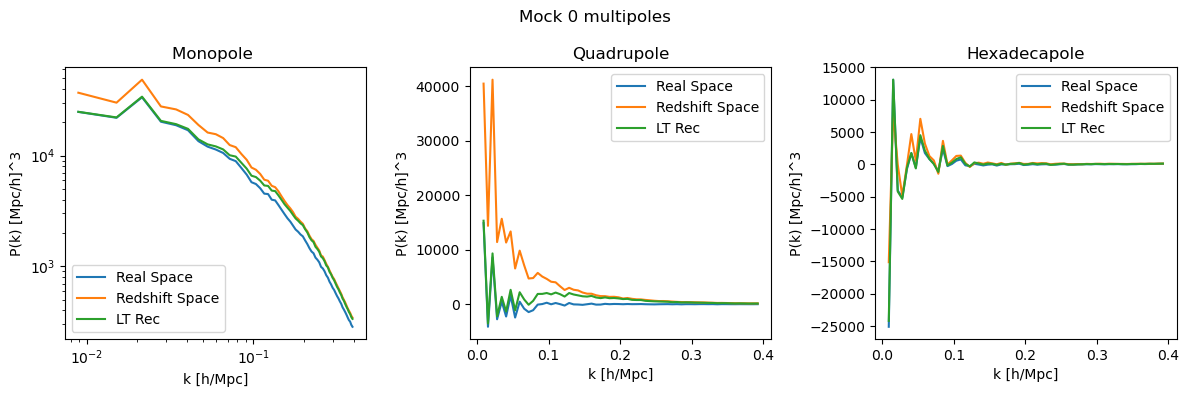

In [14]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
for i in [0,1,2]:
    axs[i].plot(k, reader.multipoles['real_space'][0][i], label='Real Space')
    axs[i].plot(k, reader.multipoles['redshift_space'][0][i], label='Redshift Space')
    axs[i].plot(k, reader.multipoles['lt_rec'][0][i], label='LT Rec')
    axs[i].legend()
    axs[i].set_xlabel('k [h/Mpc]')
    axs[i].set_ylabel('P(k) [Mpc/h]^3')
axs[0].set_title('Monopole ')
axs[1].set_title('Quadrupole')
axs[2].set_title('Hexadecapole')

axs[0].set_xscale('log')
axs[0].set_yscale('log')
fig.suptitle('Mock 0 multipoles')

fig.tight_layout()
plt.show()

In [15]:
reader.compute_mean_multipoles()

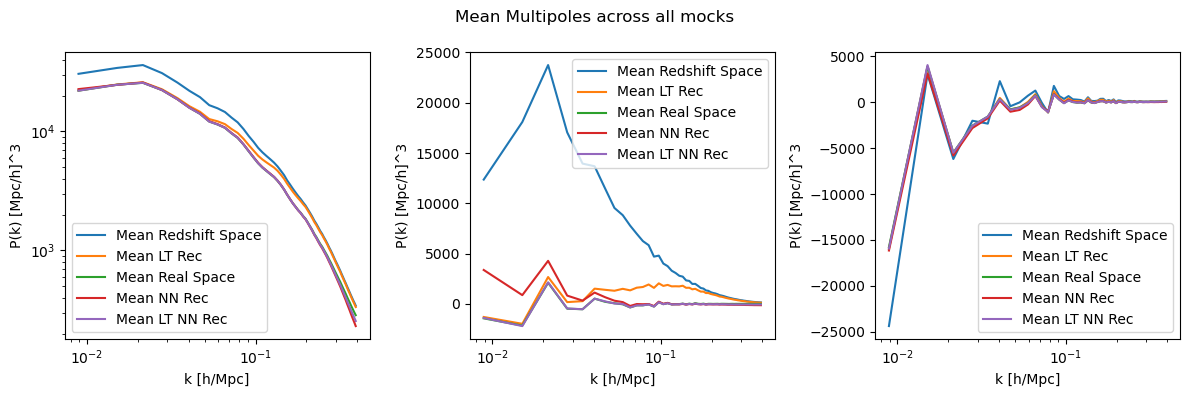

In [16]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4))

for i in [0,1,2]:
    axs[i].plot(k, reader.mean_multipoles['redshift_space'][i], label='Mean Redshift Space')
    axs[i].plot(k, reader.mean_multipoles['lt_rec'][i], label='Mean LT Rec')
    axs[i].plot(k, reader.mean_multipoles['real_space'][i], label='Mean Real Space')
    axs[i].plot(k, reader.mean_multipoles['nn_rec'][i], label='Mean NN Rec')
    axs[i].plot(k, reader.mean_multipoles['lt_nn_rec'][i], label='Mean LT NN Rec')

    axs[i].set_xlabel('k [h/Mpc]')
    axs[i].set_ylabel('P(k) [Mpc/h]^3')
    axs[i].set_xscale('log')
    axs[i].legend()

axs[0].set_yscale('log') 
fig.suptitle('Mean Multipoles across all mocks')
fig.tight_layout()
plt.show()



In [17]:
reader.residuals.keys()

dict_keys(['redshift_space', 'lt_rec', 'nn_rec', 'lt_nn_rec'])

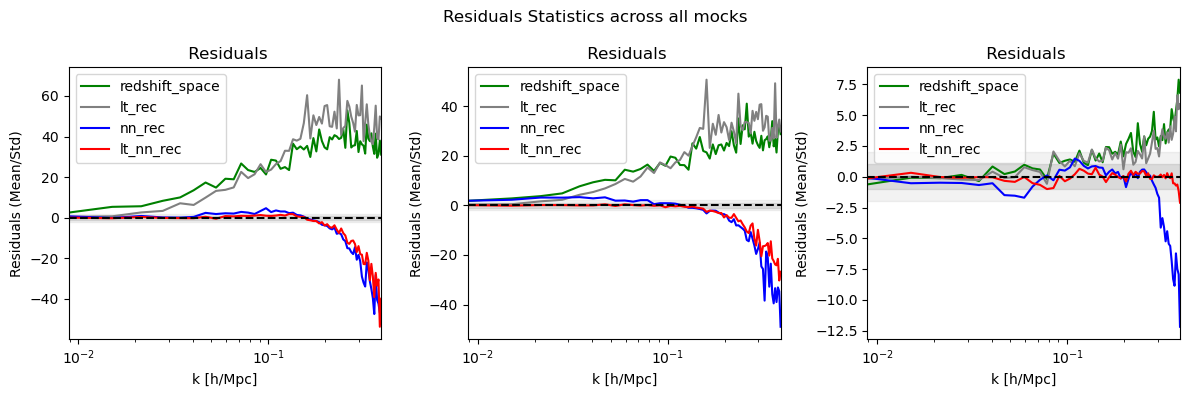

In [18]:
# plot residuals stats
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
modes = ['redshift_space', 'lt_rec', 'nn_rec', 'lt_nn_rec']
colors_dict = {
    'redshift_space': 'green',
    'lt_rec': 'grey',
    'nn_rec': 'blue',
    'lt_nn_rec': 'red'
}

for l in range(3):
    for mode in modes:
        axs[l].plot(k, reader.residuals[mode][l], label=f'{mode}', color=colors_dict[mode])
    axs[l].set_xlabel('k [h/Mpc]')
    axs[l].set_ylabel('Residuals (Mean/Std)')
    axs[l].set_xscale('log')
    axs[l].set_title(' Residuals')
    axs[l].legend()
    axs[l].axhline(0, color='black', linestyle='--')
    axs[l].fill_between(k, -1, 1, color='gray', alpha=0.2)
    axs[l].fill_between(k, -2, 2, color='gray', alpha=0.1)
    axs[l].set_xlim(min(k), max(k))


fig.suptitle('Residuals Statistics across all mocks')
fig.tight_layout()


In [19]:
reader.get_chi_squares()

{'redshift_space': {'mon': 67048.47831678852,
  'quad': 33363.962809495046,
  'hex': 572.2260376655976},
 'lt_rec': {'mon': 105035.69029349889,
  'quad': 49622.01511079161,
  'hex': 380.425675613253},
 'nn_rec': {'mon': 22191.230648095756,
  'quad': 17893.13438173845,
  'hex': 682.3081847619746},
 'lt_nn_rec': {'mon': 15226.02208736668,
  'quad': 7780.269046824292,
  'hex': 13.686875416287336}}

In [51]:
reload(sys.modules["OutputReaders"])
from OutputReaders import Plotter

(<Figure size 1400x400 with 3 Axes>,
 array([<Axes: title={'center': 'ℓ=0'}, xlabel='$k \\mathrm{[hMpc^{-1}]}$', ylabel='Residuals (Mean/Std)'>,
        <Axes: title={'center': 'ℓ=2'}, xlabel='$k \\mathrm{[hMpc^{-1}]}$', ylabel='Residuals (Mean/Std)'>,
        <Axes: title={'center': 'ℓ=4'}, xlabel='$k \\mathrm{[hMpc^{-1}]}$', ylabel='Residuals (Mean/Std)'>],
       dtype=object))

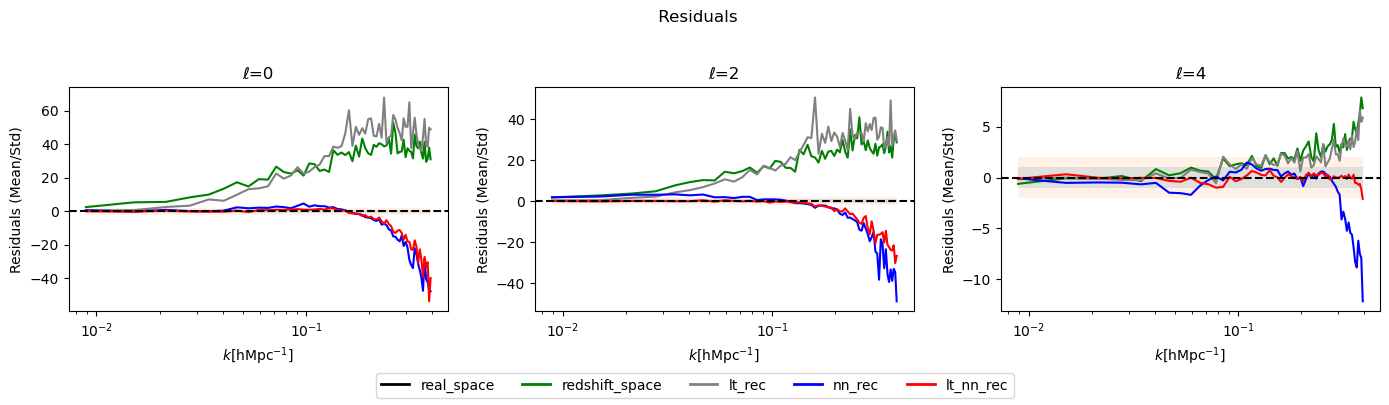

In [52]:
my_plotter = Plotter(reader)

my_plotter.plot_residuals(
    modes=['redshift_space', 'lt_rec', 'nn_rec', 'lt_nn_rec'],
    title=' Residuals'

)

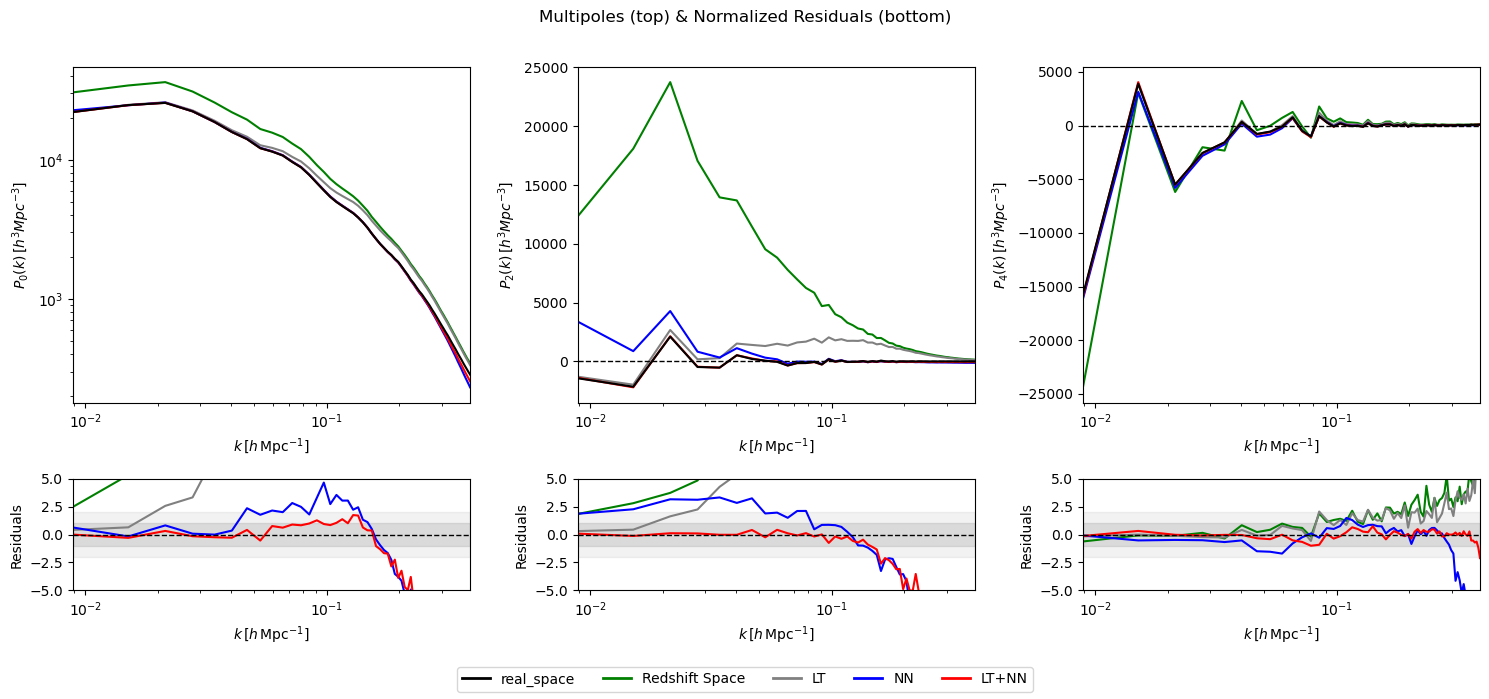

In [53]:
my_plotter.plot_multipoles_and_residuals(
    modes=['redshift_space', 'lt_rec', 'nn_rec', 'lt_nn_rec'],
    figsize=(15, 7),
    legend_labels_dict={
        'redshift_space': 'Redshift Space',
        'lt_rec': 'LT',
        'nn_rec': 'NN',
        'lt_nn_rec': 'LT+NN'},
    RESYLIM=5,
    multipoles=[0,2]
)
plt.show()